---
title: "Composition & the additive log-determinant"
short_title: "01 · Composition & log-det"
subtitle: "Why deep flows work: stack maps, and the log-determinants simply add"
description: >
  Stack bijectors T = T_K o ... o T_1 and derive the additive log-det rule
  from the chain rule. Verify it from scratch against an autodiff Jacobian,
  show why each term must be evaluated at the running intermediate, and watch
  a stack of gauss_flows blocks accumulate its log-det layer by layer —
  with orthogonal rotations contributing exactly zero.
---

(sec-nb-01)=
# 01 — Composition & the additive log-determinant

[Notebook 00](00_change_of_variables.ipynb) gave us one invertible map and its
$\log|\det J|$. But a single elementwise CDF or a single rotation cannot turn a
tangled 2D distribution into a standard Gaussian — we need to **stack** many
simple maps into a deep one. The reason stacking is cheap, and the reason
normalizing flows exist at all {cite}`rezende2015nf,dinh2017realnvp`, is a
one-line consequence of the chain rule:
**when you compose maps, their log-determinants add.**

**What you will see**

- The composition rule $\log|\det J_T| = \sum_k \log|\det J_{T_k}(x_{k-1})|$
  derived from $\det(AB) = \det A \det B$.
- A from-scratch check: the running-intermediate sum equals the autodiff
  log-det of the *whole* composition.
- Why the intermediates matter — evaluating every term at the input $x_0$ gives
  the wrong answer for nonlinear maps.
- A stack of `gauss_flows` `(rotation, marginal)` blocks accumulating its
  log-det layer by layer, with the orthogonal rotations contributing $0$.

:::{note} This is a *foundations* notebook
We hand-stack maps to expose the bookkeeping. From [Part 1](../) onward, the
stacking is done for us by `flowjax.bijections.Chain` / `Scan` inside the
`gauss_flows` flow constructors.
:::

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(1)

## 1. The composition rule

Write a deep map as a composition of $K$ bijectors,

$$
T = T_K \circ T_{K-1} \circ \cdots \circ T_1,
\qquad
x_0 = x,\quad x_k = T_k(x_{k-1}),\quad z = x_K.
$$

By the chain rule the Jacobian of the whole map is a **product** of the
per-layer Jacobians, each evaluated at the *intermediate* point it acts on:

$$
J_T(x) = J_{T_K}(x_{K-1})\, J_{T_{K-1}}(x_{K-2}) \cdots J_{T_1}(x_0).
$$

Determinants turn products into products, $\det(AB)=\det A \det B$, and logs
turn products into sums:

$$
\boxed{\;\log\big|\det J_T(x)\big| = \sum_{k=1}^{K} \log\big|\det J_{T_k}(x_{k-1})\big|\;}
$$

So the cost of a deep flow's log-det is just the **sum** of cheap per-layer
log-dets — no giant $d\times d$ determinant of the composition is ever formed.
The one subtlety the boxed formula encodes: the $k$-th term is evaluated at
$x_{k-1}$, the running state *entering* layer $k$, not at the original input.

## 2. Verify it from scratch

Take three simple invertible maps — an affine mixer, an elementwise
nonlinearity, and another affine — and compose them. We compare two ways of
getting the total log-det:

1. **Whole-composition autodiff**: build $T$, differentiate it, `slogdet`.
2. **Running-intermediate sum**: walk the layers, summing each layer's log-det
   evaluated at the state entering it.

In [2]:
A1 = jnp.asarray(rng.standard_normal((2, 2)) * 0.5 + jnp.eye(2))
A2 = jnp.asarray(rng.standard_normal((2, 2)) * 0.5 + jnp.eye(2))
b1 = jnp.asarray(rng.standard_normal(2))


def layer1(x):
    return A1 @ x + b1


def layer2(x):
    return jnp.tanh(0.8 * x) + 0.3 * x  # elementwise, monotone => invertible


def layer3(x):
    return A2 @ x


layers = [layer1, layer2, layer3]


def compose(fns):
    def T(x):
        for f in fns:
            x = f(x)
        return x
    return T


def layer_logdet(f, x):
    return jnp.linalg.slogdet(jax.jacfwd(f)(x))[1]


x = jnp.asarray(rng.standard_normal(2))

# (1) whole-composition autodiff
logdet_full = jnp.linalg.slogdet(jax.jacfwd(compose(layers))(x))[1]

# (2) running-intermediate sum
total, xk = 0.0, x
for f in layers:
    total = total + layer_logdet(f, xk)
    xk = f(xk)

print(f"whole-composition autodiff log|det J| = {logdet_full:.8f}")
print(f"running-intermediate sum             = {total:.8f}")
print(f"absolute difference                  = {abs(logdet_full - total):.2e}")
assert jnp.allclose(logdet_full, total, atol=1e-8)
print("\n[ok] composition => log-determinants add.")

whole-composition autodiff log|det J| = -0.50001264
running-intermediate sum             = -0.50001264
absolute difference                  = 2.22e-16

[ok] composition => log-determinants add.


## 3. The intermediates matter

The boxed formula evaluates layer $k$'s log-det at the running state $x_{k-1}$.
A common slip is to evaluate every layer at the original input $x_0$. For the
linear layers that happens to be fine (their Jacobian is constant), but the
nonlinear `layer2` has a Jacobian that depends on *where* it is evaluated — so
the shortcut is wrong.

In [3]:
wrong = sum(layer_logdet(f, x) for f in layers)  # all evaluated at x0 (WRONG)
print(f"correct (running intermediates) = {total:.8f}")
print(f"wrong   (all at x0)             = {wrong:.8f}")
print(f"discrepancy from nonlinearity  = {abs(total - wrong):.4f}")

correct (running intermediates) = -0.50001264
wrong   (all at x0)             = -0.35780308
discrepancy from nonlinearity  = 0.1422


The gap is entirely due to `layer2`: feeding it $x_0$ instead of $x_1 =
\text{layer1}(x_0)$ evaluates its stretch factor at the wrong point. Flow
libraries get this right by construction — each bijector receives the output
of the previous one.

## 4. The log-density of a deep flow

Combining with the change-of-variables identity from notebook 00, a deep flow
that maps data $x$ to latent $z = T(x)$ with base $p_Z = \mathcal{N}(0, I)$
scores a point as

$$
\log p_X(x) = \log p_Z\big(T(x)\big) + \sum_{k=1}^{K}\log\big|\det J_{T_k}(x_{k-1})\big|.
$$

Every layer contributes one additive term. Layers with $\log|\det J| = 0$ —
**orthogonal rotations** are the canonical example — change the geometry for
free, contributing nothing to the density bookkeeping. That is exactly why
Gaussianization alternates *rotations* (free, redistribute mass across axes)
with *marginal transforms* (do the density work). We see this next.

## 5. The bridge: a stack of `gauss_flows` blocks

A Gaussianization flow is a `Chain` of `(rotation, marginal)` blocks. Each
`gauss_flows` bijector exposes `transform_and_log_det`, and
`flowjax.bijections.Chain` composes them with *exactly* the additive rule from
§1. We build the stack by hand, push a batch of 2D data through it, and record
each sub-layer's mean log-det contribution.

In [4]:
import gauss_flows as gf
from flowjax.bijections import Chain

# A correlated, skewed 2D dataset (banana-ish) to push through the stack.
key = jr.key(0)
u = rng.standard_normal((4000, 2))
data = np.stack([u[:, 0], u[:, 1] + 0.4 * u[:, 0] ** 2 - 0.4], axis=1)
data = jnp.asarray((data - data.mean(0)) / data.std(0))

n_blocks = 4
bijectors, labels = [], []
for k in range(n_blocks):
    bijectors += [gf.HouseholderRotation(n_reflections=2, shape=(2,)),
                  gf.MixtureGaussianCDF(n_components=8, shape=(2,))]
    labels += [f"rot {k}", f"marg {k}"]

chain = Chain(bijectors)

# Per-sub-layer mean log-det, walking the running intermediates over the batch.
per_layer = []
xk = data
for bij in bijectors:
    yk, ldj = jax.vmap(bij.transform_and_log_det)(xk)
    per_layer.append(float(jnp.mean(ldj)))
    xk = yk

# Cross-check: the hand-walked sum equals Chain's own log-det (mean over batch).
_, ldj_chain = jax.vmap(chain.transform_and_log_det)(data)
print(f"sum of per-layer mean log-dets = {np.sum(per_layer):.6f}")
print(f"Chain mean log-det             = {float(jnp.mean(ldj_chain)):.6f}")
assert jnp.allclose(np.sum(per_layer), float(jnp.mean(ldj_chain)), atol=1e-6)
print("[ok] Chain accumulates the additive log-det we derived by hand.")

sum of per-layer mean log-dets = -2.406725
Chain mean log-det             = -2.406725
[ok] Chain accumulates the additive log-det we derived by hand.


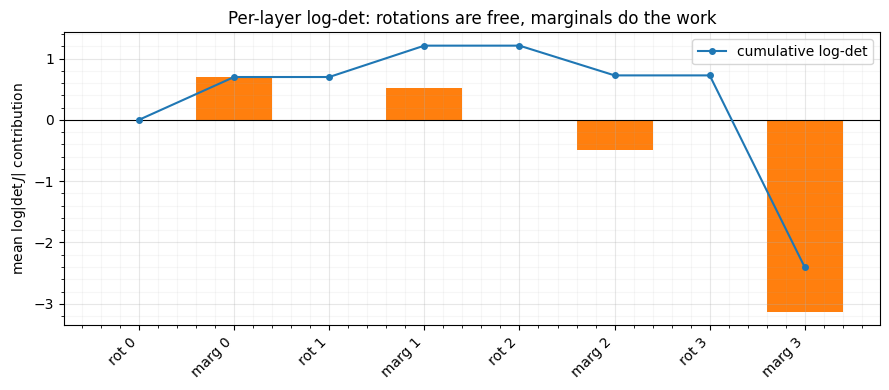

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:gray" if "rot" in l else "tab:orange" for l in labels]
ax.bar(range(len(per_layer)), per_layer, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.plot(range(len(per_layer)), np.cumsum(per_layer), "-o", color="tab:blue",
        lw=1.5, ms=4, label="cumulative log-det")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set(ylabel=r"mean $\log|\det J|$ contribution",
       title="Per-layer log-det: rotations are free, marginals do the work")
ax.legend()
style_ax(ax)
fig.tight_layout()

The grey **rotation** bars sit at exactly $0$ — orthogonal maps have
$|\det J| = 1$, so they cost nothing in the density ledger. The orange
**marginal** bars carry the entire log-det, and the blue line is their running
total: precisely the $\sum_k \log|\det J_{T_k}|$ a single `chain.log_prob`
call would add to $\log p_Z(z)$.

This decomposition is not just diagnostic. It is how every flow in this
curriculum computes a density — and it is why `gf.gaussianization_flow(...)`,
which wraps this very `Chain`, satisfies
`flow.log_prob(x) == flow.base_dist.log_prob(z) + log_det` with `z, log_det =
flow.bijection.inverse_and_log_det(x)`.

## Recap

| concept | formula | in code |
|---|---|---|
| composition Jacobian | $J_T = J_{T_K}\cdots J_{T_1}$ (chain rule) | `jax.jacfwd(compose(layers))` |
| additive log-det | $\log\lvert\det J_T\rvert=\sum_k\log\lvert\det J_{T_k}(x_{k-1})\rvert$ | running sum over layers |
| deep-flow log-density | $\log p_Z(z)+\sum_k\log\lvert\det J_{T_k}\rvert$ | `flow.log_prob(x)` |
| rotations are free | orthogonal $\Rightarrow\log\lvert\det J\rvert=0$ | grey bars at 0 |
| the library does it | additive rule inside `Chain`/`Scan` | `Chain(bijectors)` |

**Next up.** We have built maps in the data→latent direction. But which
direction should a flow *store* and which should it *compute*? In
[02 — Forward vs. inverse parameterisation](02_forward_vs_inverse.ipynb) we see
how that single choice splits flows into "good at density estimation" vs.
"good at fast sampling".